In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np

data_path = "/content/drive/MyDrive/NIDS/NIDS_processed_data"

X_train = np.load(f"{data_path}/X_train_final.npy")
X_test = np.load(f"{data_path}/X_test_final.npy")

y_train = np.load(f"{data_path}/y_train_encoded.npy")
y_test = np.load(f"{data_path}/y_test_encoded.npy")

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (1785444, 55)
Testing data: (446362, 55)
Training target: (1785444,)
Testing target: (446362,)


In [5]:
classes, counts = np.unique(y_train, return_counts=True)

print("Number of classes:", len(classes))
print("\nClass distribution:")

for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count:,}")

Number of classes: 15

Class distribution:
Class 0: 1,516,250
Class 1: 1,149
Class 2: 102,411
Class 3: 8,229
Class 4: 138,277
Class 5: 4,182
Class 6: 4,308
Class 7: 4,745
Class 8: 9
Class 9: 29
Class 10: 1,565
Class 11: 2,575
Class 12: 1,176
Class 13: 17
Class 14: 522


In [6]:
print("NaN values in training:", np.isnan(X_train).sum())
print("NaN values in testing:", np.isnan(X_test).sum())

print("Infinite values in training:", np.isinf(X_train).sum())
print("Infinite values in testing:", np.isinf(X_test).sum())

NaN values in training: 0
NaN values in testing: 0
Infinite values in training: 0
Infinite values in testing: 0


In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=100,
    n_jobs=-1,
    random_state=42
)

print("Starting Logistic Regression training...")

logistic_model.fit(X_train, y_train)

print("Training completed.")

Starting Logistic Regression training...
Training completed.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [8]:
print("Generating predictions...")

y_pred = logistic_model.predict(X_test)

print("Prediction completed.")
print("Predictions shape:", y_pred.shape)

Generating predictions...
Prediction completed.
Predictions shape: (446362,)


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall   : {recall_macro:.4f}")
print(f"Macro F1       : {f1_macro:.4f}")
print(f"Weighted F1    : {f1_weighted:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy       : 0.8222
Macro Precision: 0.2993
Macro Recall   : 0.8752
Macro F1       : 0.3552
Weighted F1    : 0.8841


In [16]:
import joblib

label_encoder = joblib.load("/content/drive/MyDrive/NIDS/NIDS_processed_data/label_encoder.pkl")

print("Label encoder loaded.")
print("Classes:", label_encoder.classes_)


Label encoder loaded.
Classes: ['Benign' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [13]:
from sklearn.metrics import classification_report

print("Classification Report")
print("-" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report
----------------------------------------------------------------------
                            precision    recall  f1-score   support

                    Benign       1.00      0.79      0.88    379064
                       Bot       0.02      0.99      0.03       288
                      DDoS       0.90      1.00      0.95     25603
             DoS GoldenEye       0.51      0.95      0.66      2057
                  DoS Hulk       0.87      0.98      0.92     34569
          DoS Slowhttptest       0.39      0.97      0.56      1046
             DoS slowloris       0.30      0.95      0.45      1077
               FTP-Patator       0.20      0.98      0.34      1186
                Heartbleed       0.03      1.00      0.06         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.05      0.96      0.09       391
               SSH-Patator       0.18      0.93      0.30       644
  Web Attack � Brute F

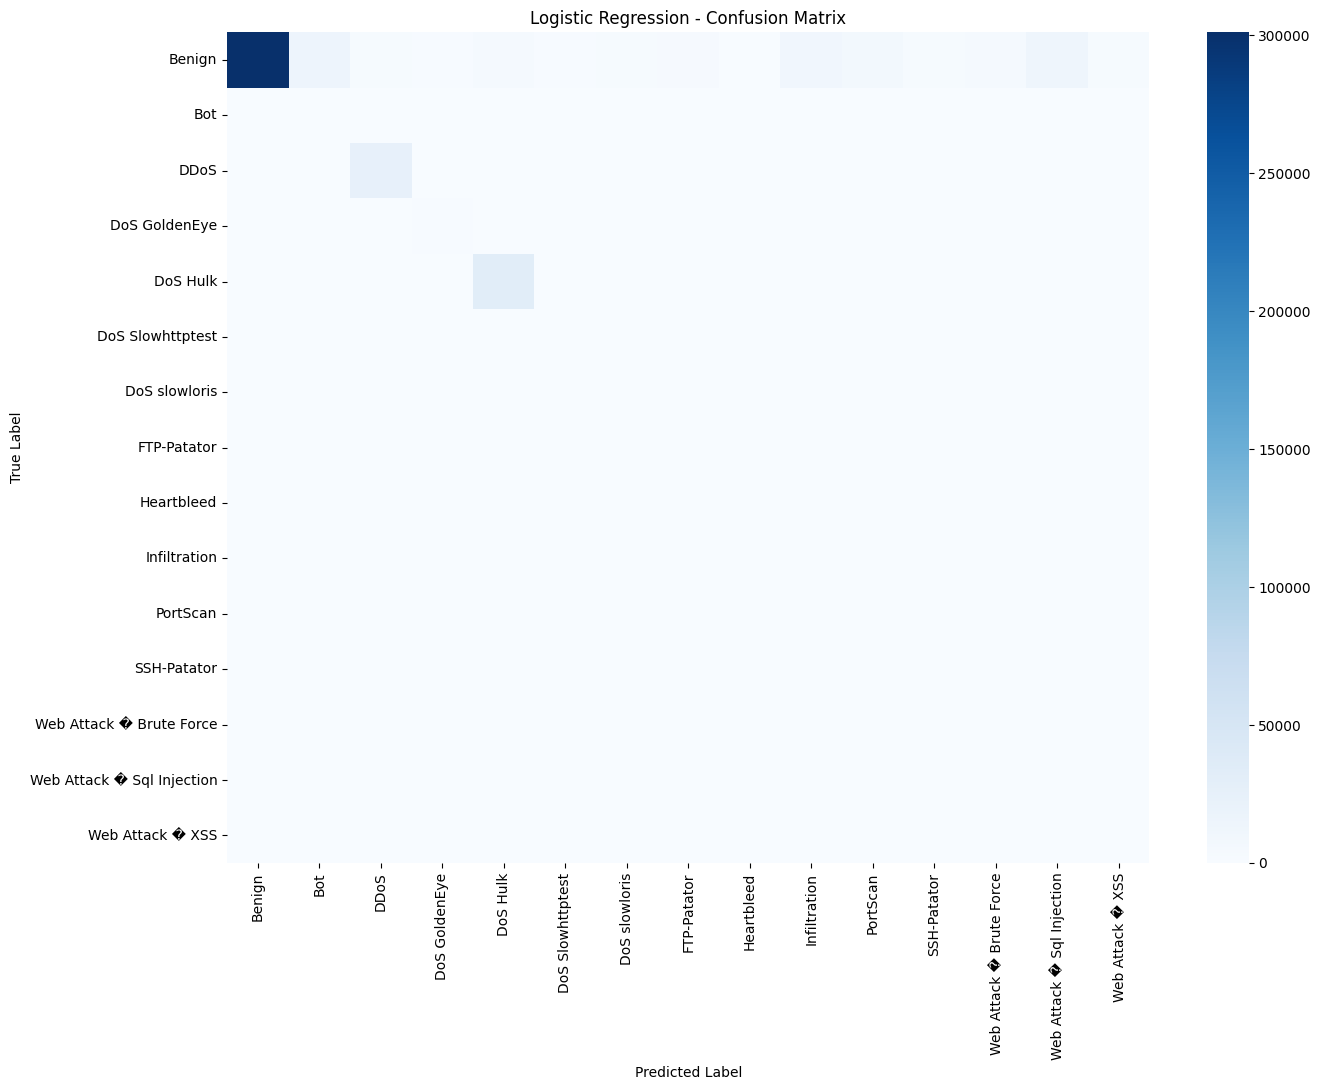

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
import os
import joblib
import json

# Create folders
os.makedirs("/content/drive/MyDrive/NIDS/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/NIDS/results", exist_ok=True)

# Save trained model
joblib.dump(
    logistic_model,
    "/content/drive/MyDrive/NIDS/models/logistic_regression.pkl"
)

# Save evaluation metrics
logistic_results = {
    "model": "Logistic Regression",
    "accuracy": accuracy,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_f1": f1_weighted
}

with open(
    "/content/drive/MyDrive/NIDS/results/logistic_regression_metrics.json",
    "w"
) as f:
    json.dump(logistic_results, f, indent=4)

print("Logistic Regression model saved.")
print("Logistic Regression metrics saved.")

Logistic Regression model saved.
Logistic Regression metrics saved.
